i start by loading the dataset and creating useful time-based features like Month.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sudan.csv")

df["Country"] = "Sudan"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

Before analysis, i clean and inspect the dataset:

- All occurrences of -999 are replaced with NaN, as they represent missing or invalid NASA data.
- Duplicate rows are checked and removed to ensure data integrity.
- Descriptive statistics  are generated to understand data distribution.
- Missing values are calculated for each column, along with their percentage.
-Columns with more than 5% missing values are highlighted because they may affect reliability and require careful handling during analysis.

In [2]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()
missing = df.isna().sum() 
percent = (missing / len(df)) * 100

i identify and handle extreme values in the dataset:

- Z-scores are computed for key weather variables to detect outliers.
- Values with |Z| > 3 are considered potential outliers.
- The number of outliers is reported for transparency.


Missing values are then handled using forward-fill or row removal depending on completeness. This ensures the dataset remains consistent for time-series analysis.

In [3]:
from scipy.stats import zscore 
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"] 
z_scores = np.abs(zscore(df[cols], nan_policy='omit')) 
outliers = (z_scores > 3).sum()
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


After cleaning, the dataset is saved into a new file for further analysis.

- The exported dataset will be used for all visualization and modeling steps.

In [4]:
df.to_csv("../data/sudan_clean.csv", index=False)


here i explored how weather variables change over time.

- Monthly average temperature (T2M) is plotted to observe seasonal patterns.
- Warmest and coolest months are identified.
- Monthly total precipitation is plotted to analyze rainfall trends.

These visualizations help reveal climate patterns such as seasonal temperature shifts and rainy seasons

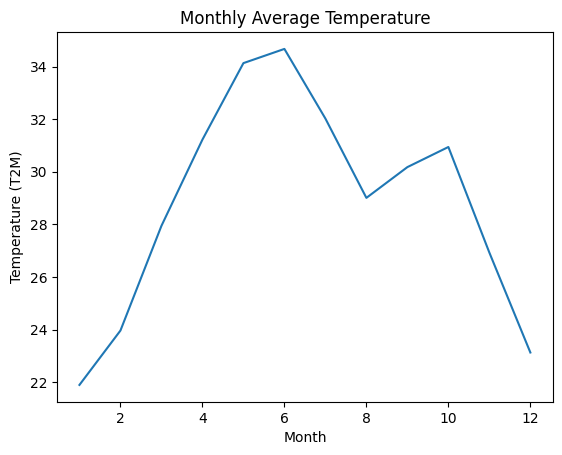

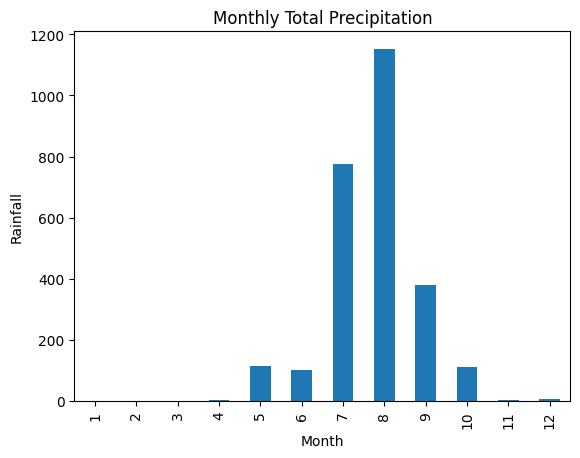

In [5]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.show()
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

i examined relationships between weather variables:

- A correlation heatmap is used to identify strong positive or negative relationships.
- Scatter plots are used to explore:
  - Temperature vs humidity
  - Temperature range vs wind speed

The three strongest correlations are identified and interpreted to understand how climate variables interact with each other.

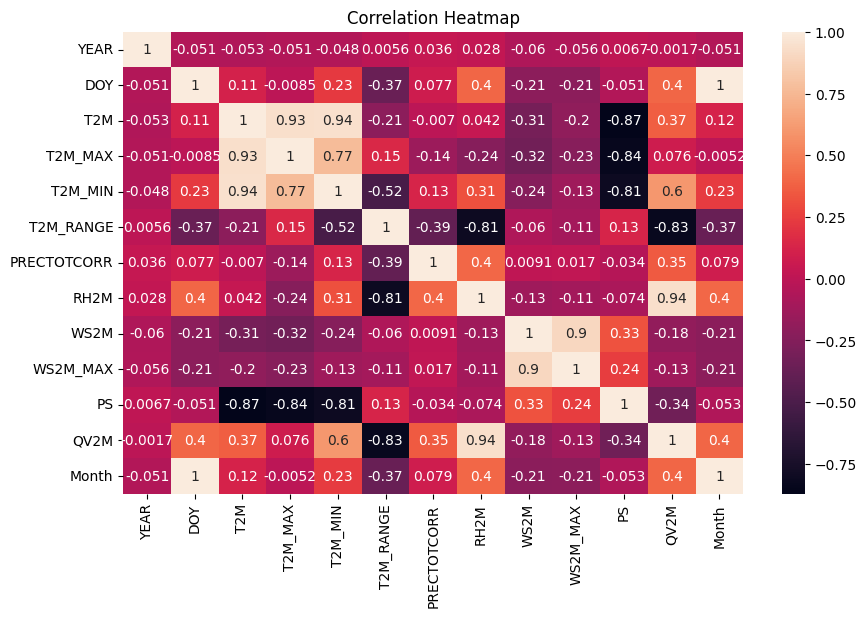

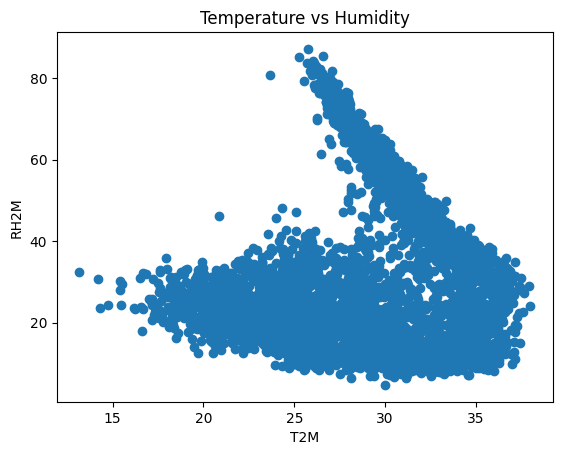

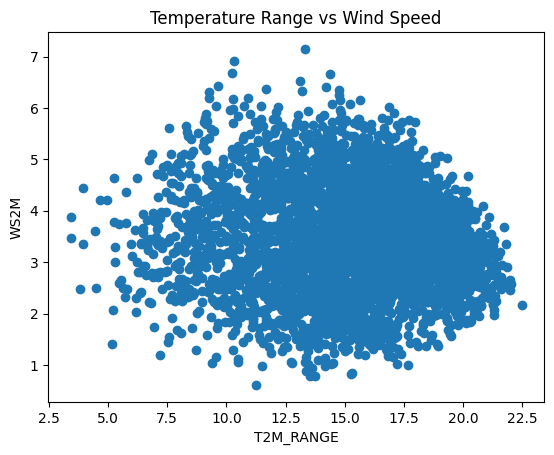

In [6]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

here i focused on understanding how values are distributed:

- A histogram of precipitation (PRECTOTCORR) is used to study rainfall distribution.
- A log scale is applied if the data is highly skewed.
- A  chart is used to visualize relationships between temperature, humidity, and rainfall intensity.

These visualizations help detect skewness, concentration, and variability in weather patterns.

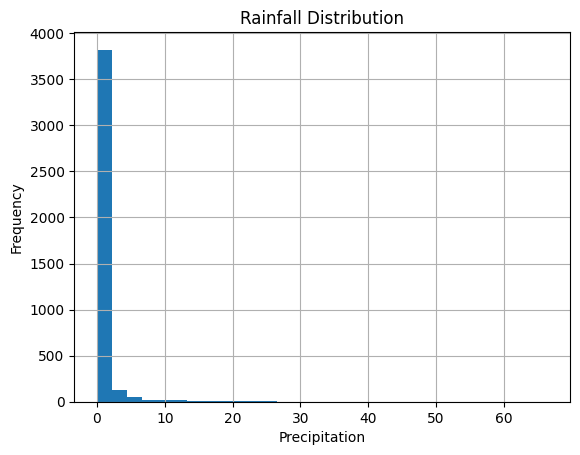

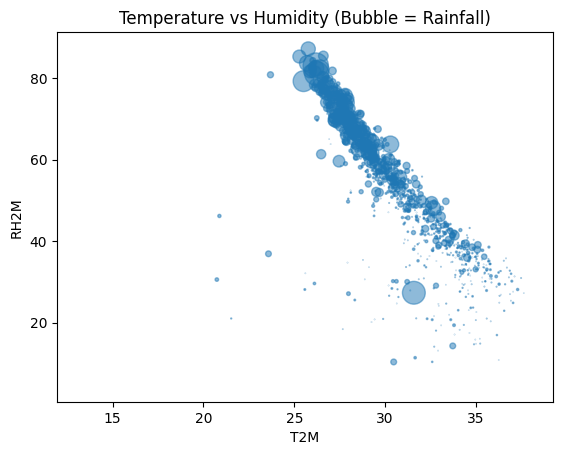

In [7]:
df["PRECTOTCORR"].hist(bins=30)
plt.title("Rainfall Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 5,  
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()